In [ ]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

In [5]:
def Csigma(a, N, sigma=0):
    b = np.zeros_like(a, dtype=np.complex64)
    for p in range(N):
        for k in range(N):
            for l in range(N):
                if p+k-l > N-1 or p+k-l < 0:
                    continue
                b[p] += (0+1j)*(p+1)*(np.min([k+1,l+1,p+k-l+1,p+1])-sigma) * a[k] * a[l] * np.conjugate(a[p+k-l])
    return b



In [6]:
def convert_to_real(a):
    return np.column_stack([a.real, a.imag]).flatten()

def convert_to_complex(a):
    shape = (int(len(a)/2), 2)
    a_reshaped = a.reshape(shape)
    return a_reshaped[:, 0] + (0+1j) * a_reshaped[:, 1]

def rhs(t, a):
    a = convert_to_complex(a)
    b = Csigma(a, N, sigma)
    return convert_to_real(b)

some notes.
what did pierre say about the trade-off between frequencies, and time-spans/time intervals
track momentum as an easy to compute conserved quantity just to see if approximation is behaving reasonably

In [ ]:
t0, tf = 0.0, 8.0
y0 = convert_to_real(np.array([0.5,0,2,1,0,0,3,0,0,0,0,0,0,0,0,0,0,0,0]))
t_eval = np.linspace(t0, tf, 10)
sigma = 0
N = 10


sol = solve_ivp(
    rhs,
    t_span=(t0, tf),
    y0=y0,
    t_eval=t_eval,
    method="RK45",
    rtol=1e-8,
    atol=1e-10,
)


In [ ]:
np.array([0.5,0,2,1,0,0,3,0,0,0,0,0,0,0,0,0,0,0,0]).shape

In [10]:
sol

  message: The solver successfully reached the end of the integration interval.
  success: True
   status: 0
        t: [ 0.000e+00  8.889e-01  1.778e+00  2.667e+00  3.556e+00
             4.444e+00  5.333e+00  6.222e+00  7.111e+00  8.000e+00]
        y: [[ 0.000e+00  0.000e+00 ...  0.000e+00  0.000e+00]
            [ 0.000e+00  0.000e+00 ...  0.000e+00  0.000e+00]
            ...
            [ 0.000e+00  0.000e+00 ...  0.000e+00  0.000e+00]
            [ 0.000e+00  0.000e+00 ...  0.000e+00  0.000e+00]]
      sol: None
 t_events: None
 y_events: None
     nfev: 13460
     njev: 0
      nlu: 0

In [44]:
sol.y.shape

(20, 10)

In [50]:
complex_sol = np.zeros((10,10), dtype=np.complex64)
for i in range(10):
    complex_sol[:,i] = convert_to_complex(sol.y[:,i])


In [47]:
np.array([[1,2], [3,4]]).T


array([[1, 3],
       [2, 4]])

In [59]:
x_points = np.linspace(0, 5, 100)
exponentials = np.exp((0+1j)*np.outer(np.arange(1,11), x_points))
final_soln = np.matmul(exponentials.T, complex_sol)
# row = time, column = space. ie final_soln[i,j] is final_soln at time t_i and space x_j
final_soln.shape

# remember during plotting that the thing is complex ! so maybe plot real/imag separately and or do one of those hea tmap type things


(100, 10)

/home/tj/Documents/Uni/Year 4/filamentation-equation/.venv/lib/python3.12/site-packages/matplotlib/cbook.py:1810: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/tj/Documents/Uni/Year 4/filamentation-equation/.venv/lib/python3.12/site-packages/matplotlib/cbook.py:1407: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asanyarray(x, float)


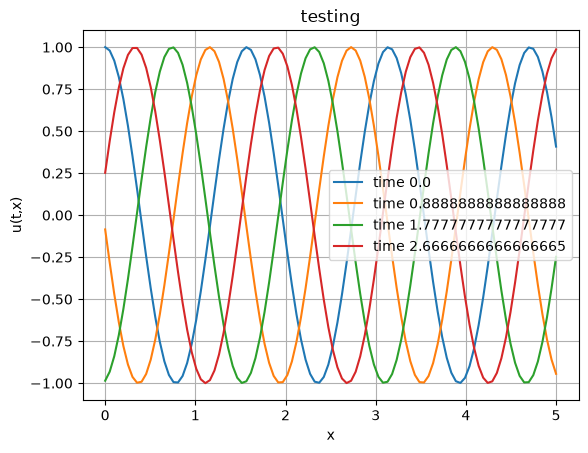

In [63]:
plt.plot(x_points, final_soln[:, 0], "-", label=f'time {sol.t[0]}')
plt.plot(x_points, final_soln[:, 1], "-", label=f'time {sol.t[1]}')
plt.plot(x_points, final_soln[:, 2], "-", label=f'time {sol.t[2]}')
plt.plot(x_points, final_soln[:, 3], "-", label=f'time {sol.t[3]}')

plt.xlabel("x")
plt.ylabel("u(t,x)")
plt.title("testing")
plt.legend()
plt.grid(True)
plt.show()

In [74]:
sol.y.shape

(20, 10)

In [69]:
test = np.array([[1,2], [3,4]])
test

array([[1, 2],
       [3, 4]])

In [73]:
np.linalg.norm(test, axis=1)

array([2.23606798, 5.        ])

In [ ]:
np.linalg.norm(complex_sol, axis=0) # the momentum would be this squared * 2pi
# for travelling waves we expect it to say around 1

array([1.        , 0.99999994, 1.        , 0.99999994, 0.99999994,
       0.99999994, 1.        , 1.        , 0.99999994, 0.99999994],
      dtype=float32)

In [ ]:
squares = np.square(np.abs(complex_sol))
mass = np.einsum("at,a->t", squares, np.array([1,1/2,1/3,1/4,1/5,1/6,1/7,1/8,1/9,1/10]))

In [1]:
mass # would expect this to remain around 1/4

NameError: name 'mass' is not defined